In [100]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [101]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [102]:
NUM_CLASSES = 27

# Dataset reading

In [103]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [104]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [106]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [107]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_10 (Dropout)        (None, 42)                0         
                                                                 
 dense_15 (Dense)            (None, 20)                860       
                                                                 
 dropout_11 (Dropout)        (None, 20)                0         
                                                                 
 dense_16 (Dense)            (None, 10)                210       
                                                                 
 dense_17 (Dense)            (None, 27)                297       
                                                                 
Total params: 1,367
Trainable params: 1,367
Non-trainable params: 0
_________________________________________________________________


In [108]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [109]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [110]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/10 [==>...........................] - ETA: 1s - loss: 3.3696 - accuracy: 0.0156
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
10/10 [==============================] - 0s 10ms/step - loss: 3.3105 - accuracy: 0.0755 - val_loss: 3.2230 - val_accuracy: 0.1443
Epoch 2/1000
 1/10 [==>...........................] - ETA: 0s - loss: 3.2411 - accuracy: 0.1719
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
10/10 [==============================] - 0s 3ms/step - loss: 3.2288 - accuracy: 0.1418 - val_loss: 3.1532 - val_accuracy: 0.2214
Epoch 3/1000
 1/10 [==>...........................] - ETA: 0s - loss: 3.1563 - accuracy: 0.1953
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
10/10 [==============================] - 0s 3ms/step - loss: 3.1282 - accuracy: 0.1642 - val_loss: 3.0620 - val_accuracy: 0.2015
Epoch 4/1000
 1/10 [==>...........................] - ETA: 0s - loss: 3.0738 - accuracy: 0.1719


In [111]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

4/4 [==============================] - 0s 580us/step - loss: 0.2433 - accuracy: 0.9577


In [112]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [113]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 33ms/step
[9.8578936e-01 7.0792717e-05 1.0087139e-02 7.2739684e-05 1.1026721e-03
 2.7943405e-03 8.2996659e-05 1.6442074e-13 5.9186244e-13 2.4959329e-13
 1.3965291e-12 5.6824235e-14 1.9516519e-12 1.4986120e-11 5.1191564e-12
 2.5911651e-13 8.7580401e-14 3.9178987e-14 2.3434447e-11 4.8221339e-13
 7.6036325e-14 1.5382578e-12 9.8004656e-13 2.6599328e-10 3.0924411e-13
 1.8240255e-11 1.0771433e-11]
0


# Confusion matrix

13/13 [==============================] - 0s 392us/step


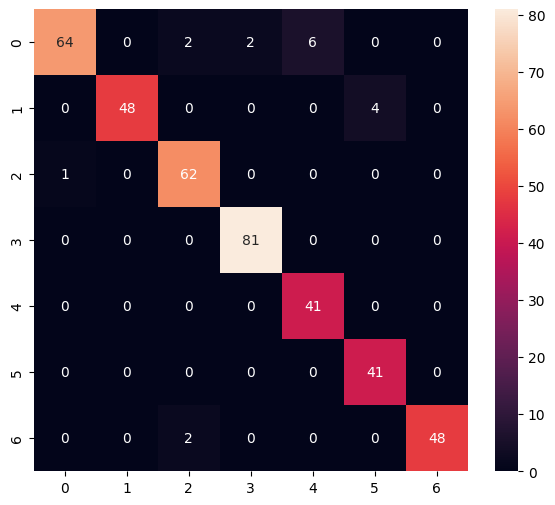

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.86      0.92        74
           1       1.00      0.92      0.96        52
           2       0.94      0.98      0.96        63
           3       0.98      1.00      0.99        81
           4       0.87      1.00      0.93        41
           5       0.91      1.00      0.95        41
           6       1.00      0.96      0.98        50

    accuracy                           0.96       402
   macro avg       0.95      0.96      0.96       402
weighted avg       0.96      0.96      0.96       402



In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [115]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [116]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmplrt8ompb/assets


INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmplrt8ompb/assets
2022-12-04 17:26:23.473239: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2022-12-04 17:26:23.473257: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2022-12-04 17:26:23.473342: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmplrt8ompb
2022-12-04 17:26:23.474203: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2022-12-04 17:26:23.474208: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmplrt8ompb
2022-12-04 17:26:23.476795: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2022-12-04 17:26:23.501323: I tensorflow/cc/saved_model/loader.cc:213] Running initialization

7620

# Inference test

In [117]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [118]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [119]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [120]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 21 µs, sys: 4 µs, total: 25 µs
Wall time: 25.7 µs


In [121]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.85789359e-01 7.07927175e-05 1.00871101e-02 7.27394799e-05
 1.10266940e-03 2.79433769e-03 8.29961064e-05 1.64420100e-13
 5.91860165e-13 2.49592312e-13 1.39652905e-12 5.68240218e-14
 1.95165195e-12 1.49860627e-11 5.11913732e-12 2.59115537e-13
 8.75800626e-14 3.91788381e-14 2.34343569e-11 4.82211601e-13
 7.60360403e-14 1.53825780e-12 9.80042761e-13 2.65992811e-10
 3.09242947e-13 1.82402548e-11 1.07713925e-11]
0
